In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.loader import DataLoader
from torch.utils.tensorboard import SummaryWriter
from halide_gnn_cost_model.data import PipelineDataset
from pathlib import Path
from tqdm.notebook import tqdm
import time

In [2]:
PIPELINES_DIR = Path("/scratch/users/fzhou48/pipelines-16k-data")
MODELS_DIR = Path("/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/resources/models")

# Create models directory if it doesn't exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
summary_writer = SummaryWriter(log_dir="resources/runs/" + time.strftime("%Y%m%d-%H%M%S"))

In [4]:
USE_GPU = True

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
elif USE_GPU and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [5]:
# Load dataset
dataset = PipelineDataset(PIPELINES_DIR)
data = dataset[0]  # Get the first pipeline graph
print(data.metadata)

1lines [00:00, 2425.86lines/s]
1lines [00:00, 6278.90lines/s]

<bound method HeteroData.metadata of HeteroData(
  y=[5],
  function={ x=[3, 1] },
  ast_node={ x=[16, 1] },
  loop_level={ x=[12, 1] },
  (function, called_by, function)={ edge_index=[2, 2] },
  (function, call, function)={ edge_index=[2, 2] },
  (ast_node, child_of, ast_node)={ edge_index=[2, 13] },
  (ast_node, parent_of, ast_node)={ edge_index=[2, 13] },
  (ast_node, is_expr_of, function)={ edge_index=[2, 3] },
  (function, contains_expr, ast_node)={ edge_index=[2, 3] },
  (loop_level, child_of, loop_level)={ edge_index=[2, 11] },
  (loop_level, parent_of, loop_level)={ edge_index=[2, 11] },
  (function, schedule_at, loop_level)={ edge_index=[2, 4] },
  (loop_level, schedule, function)={ edge_index=[2, 4] }
)>


In [6]:
# Train/test split
num_train = int(0.9 * len(dataset))
train_dataset, test_dataset = random_split(dataset, [num_train, len(dataset) - num_train])
len(train_dataset), len(test_dataset)

(14784, 1643)

In [7]:
class PipeGCN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels, num_layers=2):
        super(PipeGCN, self).__init__()
        self.convs = torch.nn.ModuleList()
        conv = SAGEConv(-1, hidden_channels, aggr="add")
        conv.reset_parameters()
        self.convs.append(conv)
        for _ in range(num_layers - 2):
            conv = SAGEConv(-1, hidden_channels, aggr="add")
            conv.reset_parameters()
            self.convs.append(conv)
        conv = SAGEConv(-1, out_channels, aggr="add")
        conv.reset_parameters()
        self.convs.append(conv)

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)
        x = self.convs[-1](x, edge_index)
        return x

In [8]:
DIM_EMBEDDING = 64
gcn = PipeGCN(hidden_channels=DIM_EMBEDDING, out_channels=DIM_EMBEDDING, num_layers=4)
gcn = to_hetero(gcn, data.metadata(), aggr="sum")

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_1' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()
/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch_geometric/nn/to_hetero_transformer.py:120: UserWarning: Found function 'dropout_2' with keyword argument 'traini

In [9]:
class PipelineModel(torch.nn.Module):
    def __init__(self, gnn, out_channels, num_runtime):
        super(PipelineModel, self).__init__()
        self.ast_embedding = nn.Embedding(num_embeddings=len(dataset.ast_vocab), embedding_dim=32)
        torch.nn.init.xavier_uniform_(self.ast_embedding.weight)
        self.sched_embedding = nn.Embedding(num_embeddings=len(dataset.sched_vocab), embedding_dim=32)
        torch.nn.init.xavier_uniform_(self.sched_embedding.weight)
        self.function_gnn = gnn
        self.pipeline_lin = torch.nn.Linear(out_channels, num_runtime)
        torch.nn.init.xavier_uniform_(self.pipeline_lin.weight)

    def forward(self, data, ptr=None):
        data["ast_node"].x = self.ast_embedding(data["ast_node"].x.squeeze())
        data["loop_level"].x = self.sched_embedding(data["loop_level"].x.squeeze())
        x_dict = data.x_dict
        edge_index_dict = data.edge_index_dict
        out = self.function_gnn(x_dict, edge_index_dict)
        # Get the feature of the pipeline node
        start = 0 if ptr is None else ptr[:-1]
        end = -1 if ptr is None else ptr[1:] - 1
        cum_sum = out["loop_level"].cumsum(dim=0)
        pipeline_feat = cum_sum[end] - cum_sum[start]
        # Predict the runtime
        log_runtime = self.pipeline_lin(pipeline_feat)
        return log_runtime

In [10]:
model = PipelineModel(gcn, DIM_EMBEDDING, 5)
model = model.to(device)
model

PipelineModel(
  (ast_embedding): Embedding(14, 32)
  (sched_embedding): Embedding(8, 32)
  (function_gnn): GraphModule(
    (convs): ModuleList(
      (0-3): 4 x ModuleDict(
        (function__called_by__function): SAGEConv(-1, 64, aggr=add)
        (function__call__function): SAGEConv(-1, 64, aggr=add)
        (ast_node__child_of__ast_node): SAGEConv(-1, 64, aggr=add)
        (ast_node__parent_of__ast_node): SAGEConv(-1, 64, aggr=add)
        (ast_node__is_expr_of__function): SAGEConv(-1, 64, aggr=add)
        (function__contains_expr__ast_node): SAGEConv(-1, 64, aggr=add)
        (loop_level__child_of__loop_level): SAGEConv(-1, 64, aggr=add)
        (loop_level__parent_of__loop_level): SAGEConv(-1, 64, aggr=add)
        (function__schedule_at__loop_level): SAGEConv(-1, 64, aggr=add)
        (loop_level__schedule__function): SAGEConv(-1, 64, aggr=add)
      )
    )
  )
  (pipeline_lin): Linear(in_features=64, out_features=5, bias=True)
)

In [11]:
data_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=4)
data_loader

/home/groups/kayvonf/fzhou48/halide-gnn-cost-model/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 3, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [12]:
for batch in data_loader:
    batch = batch.to(device)
    print(batch)
    print(model(batch, batch["loop_level"].ptr))
    break

HeteroDataBatch(
  y=[1280],
  function={
    x=[1452, 1],
    batch=[1452],
    ptr=[257],
  },
  ast_node={
    x=[9728, 1],
    batch=[9728],
    ptr=[257],
  },
  loop_level={
    x=[5698, 1],
    batch=[5698],
    ptr=[257],
  },
  (function, called_by, function)={ edge_index=[2, 1465] },
  (function, call, function)={ edge_index=[2, 1465] },
  (ast_node, child_of, ast_node)={ edge_index=[2, 8276] },
  (ast_node, parent_of, ast_node)={ edge_index=[2, 8276] },
  (ast_node, is_expr_of, function)={ edge_index=[2, 1452] },
  (function, contains_expr, ast_node)={ edge_index=[2, 1452] },
  (loop_level, child_of, loop_level)={ edge_index=[2, 5442] },
  (loop_level, parent_of, loop_level)={ edge_index=[2, 5442] },
  (function, schedule_at, loop_level)={ edge_index=[2, 1624] },
  (loop_level, schedule, function)={ edge_index=[2, 1624] }
)
tensor([[-43.7885, -11.0247,  56.3241,  17.6412,  -3.1729],
        [-10.4905,  -5.9971,  10.2806,  34.3139,   7.3493],
        [-79.3222,  26.1054,  45.

In [13]:
# Save model every n epochs
SAVE_EVERY = 25

# Train loop (example)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
criterion = torch.nn.MSELoss()

for epoch in tqdm(range(200)):
    model.train()
    total_loss = 0
    for batch_idx, batch in enumerate(data_loader):
        optimizer.zero_grad()
        batch = batch.to(device)
        pred = model(batch, batch["loop_level"].ptr)
        # Assuming batch.y contains the true runtimes
        loss = criterion(pred.reshape(-1), torch.log(batch.y))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        summary_writer.add_scalar("Loss/train", loss.item(), epoch * len(data_loader) + batch_idx)
    # Print average loss for the epoch
    avg_loss = total_loss / len(data_loader)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    # Save model
    if (epoch + 1) % SAVE_EVERY == 0:
        torch.save(model.state_dict(), MODELS_DIR / f"pipeline_model_epoch_{epoch+1}.pt")

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1, Loss: 65.0047
Epoch 2, Loss: 2.7676
Epoch 3, Loss: 2.4426
Epoch 4, Loss: 2.1997
Epoch 5, Loss: 2.0362
Epoch 6, Loss: 1.8984
Epoch 7, Loss: 1.7903
Epoch 8, Loss: 1.7313
Epoch 9, Loss: 1.6590
Epoch 10, Loss: 1.6061
Epoch 11, Loss: 1.5836
Epoch 12, Loss: 1.5393
Epoch 13, Loss: 1.5204
Epoch 14, Loss: 1.4868
Epoch 15, Loss: 1.4738
Epoch 16, Loss: 1.4428
Epoch 17, Loss: 1.4259
Epoch 18, Loss: 1.4004
Epoch 19, Loss: 1.3928
Epoch 20, Loss: 1.3818
Epoch 21, Loss: 1.3584
Epoch 22, Loss: 1.3534
Epoch 23, Loss: 1.3412
Epoch 24, Loss: 1.3290
Epoch 25, Loss: 1.3023
Epoch 26, Loss: 1.3091
Epoch 27, Loss: 1.2882
Epoch 28, Loss: 1.2824
Epoch 29, Loss: 1.2620
Epoch 30, Loss: 1.2590
Epoch 31, Loss: 1.2407
Epoch 32, Loss: 1.2475
Epoch 33, Loss: 1.2347
Epoch 34, Loss: 1.2254
Epoch 35, Loss: 1.2029
Epoch 36, Loss: 1.1796
Epoch 37, Loss: 1.1513
Epoch 38, Loss: 1.1376
Epoch 39, Loss: 1.1276
Epoch 40, Loss: 1.1121
Epoch 41, Loss: 1.1112
Epoch 42, Loss: 1.0964
Epoch 43, Loss: 1.0942
Epoch 44, Loss: 1.0

# Eval

In [14]:
def average_runtime_error(model, data_loader):
    model.eval()
    total_error = 0
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            pred = model(batch, batch["loop_level"].ptr)
            error_rates = torch.abs(pred.reshape(-1) - batch.y) / batch.y
            total_error += torch.mean(error_rates).item()
    return total_error / len(data_loader)

In [15]:
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(f"Average Runtime Error on Test Set: {average_runtime_error(model, test_loader) * 100:.2f}%")

Average Runtime Error on Test Set: 333.87%


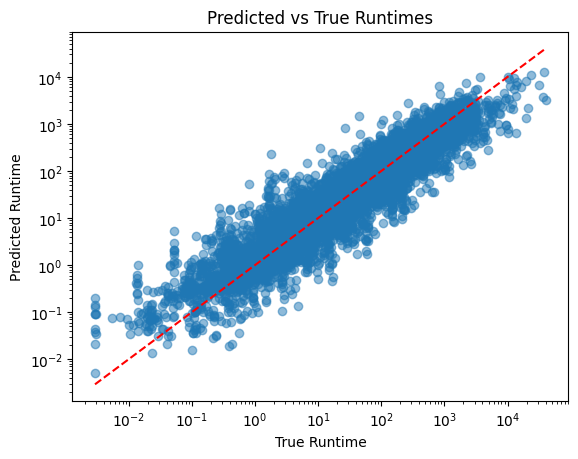

In [16]:
# Plot predicted vs actual runtimes
import matplotlib.pyplot as plt
all_preds = []
all_trues = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = torch.exp(model(batch, batch["loop_level"].ptr))
        all_preds.append(pred.reshape(-1).cpu())
        all_trues.append(batch.y.cpu())
all_preds = torch.cat(all_preds)
all_trues = torch.cat(all_trues)
plt.scatter(all_trues, all_preds, alpha=0.5)
plt.plot([all_trues.min(), all_trues.max()], [all_trues.min(), all_trues.max()], 'r--')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("True Runtime")
plt.ylabel("Predicted Runtime")
plt.title("Predicted vs True Runtimes")
plt.show()

In [17]:
idx = 0  # Index of the sample to inspect
model.eval()
with torch.no_grad():
    sample_data = test_dataset[idx]
    sample_data = sample_data.to(device)
    pred_runtime = torch.exp(model(sample_data))
    print(f"Predicted runtime: {pred_runtime}, True runtime: {sample_data.y}")

Predicted runtime: tensor([  1.8882,   7.4662,  38.1597, 146.9496, 712.5017], device='cuda:0'), True runtime: tensor([   3.8287,   18.0807,   88.4883,  463.7128, 3677.9753],
       device='cuda:0')
